In [2]:
import rasterio
import numpy as np
from pyproj import Transformer
from rasterio.windows import from_bounds

# --- Setup coordinate transform (Moon South Polar Stereographic) ---
moon_radius = 1737400
src_proj = f"+proj=longlat +R={moon_radius} +no_defs"
dst_proj = f"+proj=stere +lat_0=-90 +lat_ts=-90 +lon_0=0 +k=1 +x_0=0 +y_0=0 +R={moon_radius} +units=m +no_defs"
transformer = Transformer.from_crs(src_proj, dst_proj, always_xy=True)

candidate_lat, candidate_lon = -84.098, 79.764
cx, cy = transformer.transform(candidate_lon, candidate_lat)
print(f"Candidate projected coords: X={cx:.1f}, Y={cy:.1f}")

# --- Load and crop the DEM (elevation, not slope this time — we need raw elevation) ---
dem_path = 'https://pgda.gsfc.nasa.gov/data/LOLA_20mpp/LDSM_80S_20MPP_ADJ.TIF'  # adjust to your actual DEM file path

with rasterio.open(dem_path) as src:
    dem_transform = src.transform
    pixel_size = src.res[0]  # ground resolution in meters
    buffer_m = 5000
    bounds = (cx - buffer_m, cy - buffer_m, cx + buffer_m, cy + buffer_m)
    window = from_bounds(*bounds, transform=dem_transform)
    dem_crop = src.read(1, window=window).astype(float)

print("DEM crop shape:", dem_crop.shape)
print("Pixel size (m):", pixel_size)
print("Elevation range:", np.nanmin(dem_crop), "to", np.nanmax(dem_crop))

Candidate projected coords: X=176275.9, Y=31831.4
DEM crop shape: (500, 500)
Pixel size (m): 20.0
Elevation range: 0.00700597558170557 to 59.308616638183594


In [3]:
from scipy.ndimage import sobel, uniform_filter, rotate

def compute_slope(dem, pixel_size):
    dz_dx = sobel(dem, axis=1) / (8.0 * pixel_size)
    dz_dy = sobel(dem, axis=0) / (8.0 * pixel_size)
    slope_rad = np.arctan(np.sqrt(dz_dx**2 + dz_dy**2))
    return np.degrees(slope_rad)

def compute_aspect(dem, pixel_size):
    dz_dx = sobel(dem, axis=1) / (8.0 * pixel_size)
    dz_dy = sobel(dem, axis=0) / (8.0 * pixel_size)
    aspect_rad = np.arctan2(-dz_dx, dz_dy)
    return np.degrees(aspect_rad) % 360.0

def compute_roughness_rms(dem, window_size=5):
    local_mean = uniform_filter(dem.astype(np.float64), size=window_size)
    local_mean_sq = uniform_filter(dem.astype(np.float64)**2, size=window_size)
    variance = np.maximum(local_mean_sq - local_mean**2, 0.0)
    return np.sqrt(variance)

def compute_illumination(dem, sun_elevation_deg, sun_azimuth_deg, pixel_size):
    rows, cols = dem.shape
    tan_elev = np.tan(np.radians(sun_elevation_deg))
    angle = 270.0 - sun_azimuth_deg
    dem_rot = rotate(dem, angle, reshape=True, mode='nearest')
    cols_rot = dem_rot.shape[1]
    x_coords = np.arange(cols_rot) * pixel_size
    H_eff = dem_rot - x_coords[np.newaxis, :] * tan_elev
    H_max = np.maximum.accumulate(H_eff, axis=1)
    shadow_rot = H_eff < (H_max - 1e-4)
    shadow_full = rotate(shadow_rot, -angle, reshape=False, order=0)
    r_center, c_center = shadow_full.shape[0]/2.0, shadow_full.shape[1]/2.0
    r_start = int(round(r_center - rows/2.0))
    c_start = int(round(c_center - cols/2.0))
    shadow = shadow_full[r_start:r_start+rows, c_start:c_start+cols]
    return ~shadow

def compute_cumulative_illumination(dem, pixel_size, n_azimuths=8, sun_elevations=[5, 10, 15]):
    # Kept SMALL (8 azimuths x 3 elevations = 24 passes) for speed — increase later if time allows
    rows, cols = dem.shape
    accum = np.zeros((rows, cols), dtype=np.float64)
    azimuths = np.linspace(0, 360, n_azimuths, endpoint=False)
    count = 0
    for elev in sun_elevations:
        for az in azimuths:
            lit = compute_illumination(dem, elev, az, pixel_size)
            accum += lit.astype(np.float64)
            count += 1
    return accum / count if count > 0 else accum

def compute_hazard_map(slope, roughness, illumination_frac, weights=None):
    if weights is None:
        weights = {'slope': 1/3, 'roughness': 1/3, 'illumination': 1/3}
    def _normalise(arr):
        a_min, a_max = np.nanmin(arr), np.nanmax(arr)
        denom = a_max - a_min
        return np.zeros_like(arr) if denom == 0 else (arr - a_min) / denom
    slope_norm = _normalise(slope)
    rough_norm = _normalise(roughness)
    illum_inv = 1.0 - np.clip(illumination_frac, 0.0, 1.0)
    hazard = (weights['slope']*slope_norm + weights['roughness']*rough_norm + weights['illumination']*illum_inv)
    return np.clip(hazard / sum(weights.values()), 0.0, 1.0)

In [4]:
print("Computing slope...")
slope = compute_slope(dem_crop, pixel_size)

print("Computing aspect...")
aspect = compute_aspect(dem_crop, pixel_size)

print("Computing roughness...")
roughness = compute_roughness_rms(dem_crop)

print("Computing illumination (this may take a minute)...")
illum_frac = compute_cumulative_illumination(dem_crop, pixel_size, n_azimuths=8, sun_elevations=[5, 10, 15])

print("Computing combined hazard map...")
hazard = compute_hazard_map(slope, roughness, illum_frac)

print("Done. Shapes:", slope.shape, roughness.shape, illum_frac.shape, hazard.shape)

Computing slope...
Computing aspect...
Computing roughness...
Computing illumination (this may take a minute)...
Computing combined hazard map...
Done. Shapes: (500, 500) (500, 500) (500, 500) (500, 500)


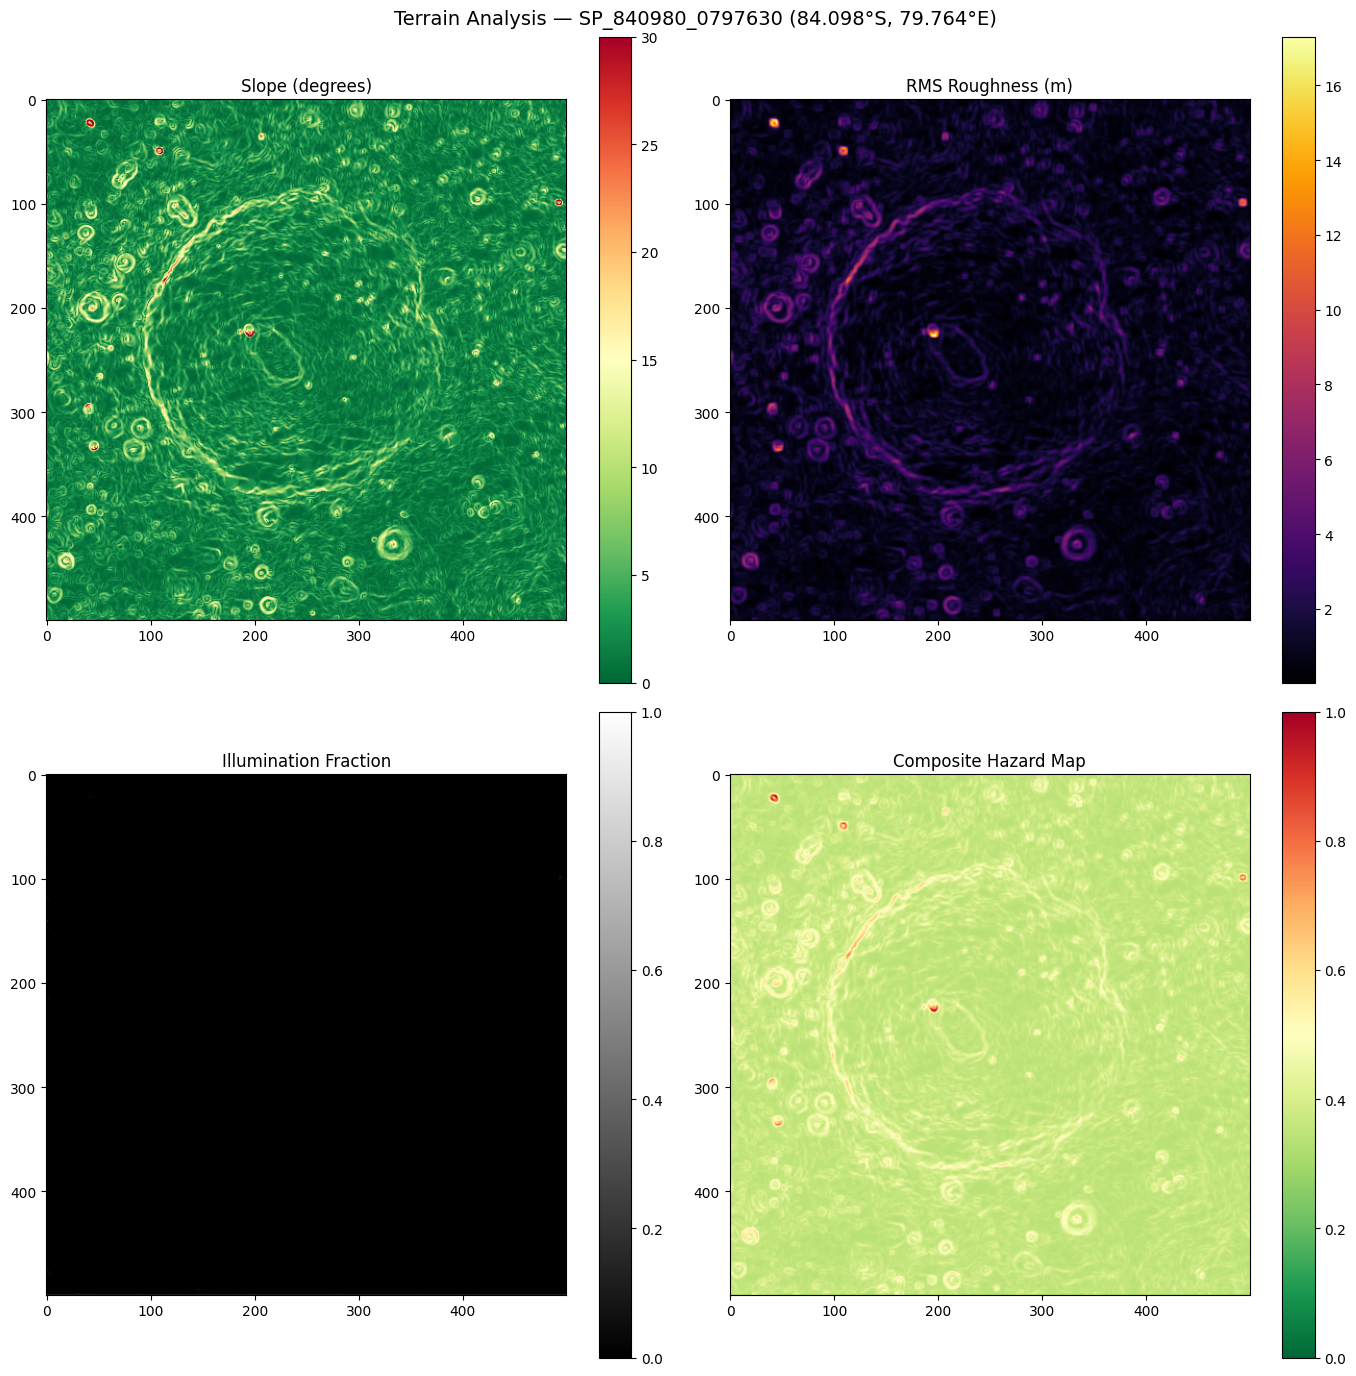

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 14))

im0 = axes[0,0].imshow(slope, cmap='RdYlGn_r', vmin=0, vmax=30)
axes[0,0].set_title('Slope (degrees)')
plt.colorbar(im0, ax=axes[0,0])

im1 = axes[0,1].imshow(roughness, cmap='inferno')
axes[0,1].set_title('RMS Roughness (m)')
plt.colorbar(im1, ax=axes[0,1])

im2 = axes[1,0].imshow(illum_frac, cmap='gray', vmin=0, vmax=1)
axes[1,0].set_title('Illumination Fraction')
plt.colorbar(im2, ax=axes[1,0])

im3 = axes[1,1].imshow(hazard, cmap='RdYlGn_r', vmin=0, vmax=1)
axes[1,1].set_title('Composite Hazard Map')
plt.colorbar(im3, ax=axes[1,1])

plt.suptitle('Terrain Analysis — SP_840980_0797630 (84.098°S, 79.764°E)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/terrain_analysis_full.png', dpi=200, bbox_inches='tight')
plt.show()

In [6]:
safe_mask = hazard < 0.33
caution_mask = (hazard >= 0.33) & (hazard < 0.66)
hazard_mask = hazard >= 0.66

print(f"Safe: {np.sum(safe_mask)/hazard.size*100:.1f}%")
print(f"Caution: {np.sum(caution_mask)/hazard.size*100:.1f}%")
print(f"Hazard: {np.sum(hazard_mask)/hazard.size*100:.1f}%")

Safe: 0.6%
Caution: 99.3%
Hazard: 0.1%


In [7]:
from google.colab import files
files.download('/content/terrain_analysis_full.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>